In [43]:
import geopandas as gpd
from pathlib import Path

def load_collision_data_multi_year(folder_path: str) -> gpd.GeoDataFrame:

    folder = Path(folder_path)
    files = sorted(folder.glob("*.csv"))

    if not files:
        raise ValueError("No CSV files found in folder")

    print(f"Found {len(files)} files")

    gdfs = []
    for f in files:
        print(f"Loading: {f.name}")
        gdf_year = load_collision_data(str(f))
        gdfs.append(gdf_year)

    gdf = pd.concat(gdfs, ignore_index=True)

    print("Combined shape:", gdf.shape)

    return gdf

In [2]:
def load_collision_data(path: str) -> gpd.GeoDataFrame:
    df = pd.read_csv(path, sep=";", encoding="latin1", low_memory=False)

    df = df.rename(columns={
        "Datum": "datetime",
        "Viltslag": "species",
        "Län": "lan",
        "Kommun": "kommun",
        "Lat WGS84": "lat",
        "Long WGS84": "lon",
    })

    df["lat"] = df["lat"].astype(str).str.replace(",", ".", regex=False)
    df["lon"] = df["lon"].astype(str).str.replace(",", ".", regex=False)

    df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
    df["lon"] = pd.to_numeric(df["lon"], errors="coerce")
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce", dayfirst=False)

    df = df.dropna(subset=["datetime", "lat", "lon"]).copy()

    # Keep only plausible Sweden WGS84 coordinates
    df = df[
        df["lat"].between(55, 70) &
        df["lon"].between(10, 25)
    ].copy()

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326"
    ).to_crs("EPSG:3006")

    return gdf

In [3]:
import pandas as pd
from grid import create_grid
from grid import spatial_join_points_to_grid

def build_cell_month_table_full(gdf_points, cell_size=10000):

    # Create grid
    grid = create_grid(gdf_points, cell_size=cell_size)

    # Join points to grid
    joined = spatial_join_points_to_grid(gdf_points, grid)
    joined = joined.dropna(subset=["cell_id"]).copy()
    joined["cell_id"] = joined["cell_id"].astype(int)

    # Month column
    joined["period_start"] = joined["datetime"].dt.to_period("M").dt.to_timestamp()

    # Count collisions per observed cell-month
    observed = (
        joined.groupby(["cell_id", "period_start"])
        .size()
        .reset_index(name="collision_count")
    )

    print("\nSample collisions per grid cell and month:")
    print(observed.head(10))


    # Build full set of months in study period
    min_month = gdf_points["datetime"].dt.to_period("M").min().to_timestamp()
    max_month = gdf_points["datetime"].dt.to_period("M").max().to_timestamp()

    all_months = pd.date_range(start=min_month, end=max_month, freq="MS")

    # Build full cell x month panel
    full_index = pd.MultiIndex.from_product(
        [grid["cell_id"].astype(int).unique(), all_months],
        names=["cell_id", "period_start"]
    )

    full_panel = full_index.to_frame(index=False)

    # Merge observed counts into full panel
    cell_month = full_panel.merge(
        observed,
        on=["cell_id", "period_start"],
        how="left"
    )

    cell_month["collision_count"] = cell_month["collision_count"].fillna(0).astype(int)


    # Define high-risk using top 25% of nonzero collision counts
    nonzero_counts = cell_month.loc[cell_month["collision_count"] > 0, "collision_count"]

    if nonzero_counts.empty:
        raise ValueError("No nonzero collision counts found; cannot define high-risk threshold.")

    threshold = nonzero_counts.quantile(0.75)

    cell_month["risk"] = (cell_month["collision_count"] >= threshold).astype(int)

    print("High-risk threshold:", threshold)
    print(cell_month["risk"].value_counts())

    return grid, joined, cell_month

In [4]:
gdf = load_collision_data_multi_year(
    "C:/Users/Amanda/PycharmProjects/thesis_boogaloo/data/Collisions"
)

gdf = gdf[gdf["datetime"].dt.year <= 2025].copy()

print(gdf.shape)
print(gdf["datetime"].min(), "→", gdf["datetime"].max())

print(gdf["datetime"].dt.year.value_counts().sort_index())

grid, joined, cell_month = build_cell_month_table_full(gdf, cell_size=10000) #Vi kan ändra detta beronde på, gjorde den bara lite mindre pga tid

print(cell_month.head())
print(cell_month.shape)
print(cell_month["collision_count"].describe())
print(cell_month["risk"].value_counts())

Found 12 files
Loading: Rådata 2015.csv
Loading: Rådata 2016.csv
Loading: Rådata 2017.csv
Loading: Rådata 2018.csv
Loading: Rådata 2019.csv
Loading: Rådata 2020.csv
Loading: Rådata 2021.csv
Loading: Rådata 2022.csv
Loading: Rådata 2023.csv
Loading: Rådata 2024.csv
Loading: Rådata 2025.csv
Loading: Rådata 2026.csv
Combined shape: (732678, 16)
(712512, 16)
2015-01-01 00:21:00 → 2025-12-31 23:55:00
datetime
2015    44813
2016    56361
2017    58731
2018    63493
2019    64414
2020    62171
2021    68469
2022    67848
2023    71387
2024    77715
2025    77110
Name: count, dtype: int64

Sample collisions per grid cell and month:
   cell_id period_start  collision_count
0       12   2024-05-01                1
1       23   2024-10-01                1
2       28   2016-09-01                1
3       40   2024-05-01                1
4       42   2023-05-01                1
5       49   2021-09-01                1
6      184   2018-07-01                1
7      185   2021-07-01                1

In [5]:
import pandas as pd
import numpy as np

gdf_daylight = load_collision_data_multi_year(
    "C:/Users/Amanda/PycharmProjects/thesis_boogaloo/data/Collisions"
)
daylight_df = gdf_daylight.copy()
daylight_df["datetime"] = pd.to_datetime(daylight_df["datetime"], errors="coerce")
daylight_df = daylight_df.dropna(subset=["datetime"]).copy()

daylight_df["hour"] = daylight_df["datetime"].dt.hour
daylight_df["month"] = daylight_df["datetime"].dt.month
daylight_df["species"] = daylight_df["species"].astype(str).str.strip().str.lower()

species_map = {
    "älg": "moose",
    "rådjur": "roe_deer",
    "vildsvin": "wild_boar",
    "dovhjort": "fallow_deer",
}
daylight_df["species"] = daylight_df["species"].replace(species_map)

def classify_light_proxy(row):
    hour = row["hour"]
    month = row["month"]

    # Winter
    if month in [12, 1, 2]:
        if 9 <= hour < 15:
            return "day"
        elif 7 <= hour < 9:
            return "dawn"
        elif 15 <= hour < 17:
            return "dusk"
        else:
            return "night"

    # Summer
    elif month in [6, 7, 8]:
        if 5 <= hour < 21:
            return "day"
        elif 3 <= hour < 5:
            return "dawn"
        elif 21 <= hour < 23:
            return "dusk"
        else:
            return "night"

    # Spring & Autumn
    else:
        if 7 <= hour < 18:
            return "day"
        elif 5 <= hour < 7:
            return "dawn"
        elif 18 <= hour < 20:
            return "dusk"
        else:
            return "night"

daylight_df["light_condition"] = daylight_df.apply(classify_light_proxy, axis=1)

print(daylight_df[["datetime", "hour", "species", "light_condition"]].head())

Found 12 files
Loading: Rådata 2015.csv
Loading: Rådata 2016.csv
Loading: Rådata 2017.csv
Loading: Rådata 2018.csv
Loading: Rådata 2019.csv
Loading: Rådata 2020.csv
Loading: Rådata 2021.csv
Loading: Rådata 2022.csv
Loading: Rådata 2023.csv
Loading: Rådata 2024.csv
Loading: Rådata 2025.csv
Loading: Rådata 2026.csv
Combined shape: (732678, 16)
             datetime  hour      species light_condition
0 2015-01-01 00:21:00     0  fallow_deer           night
1 2015-01-01 01:30:00     1        moose           night
2 2015-01-01 01:36:00     1    wild_boar           night
3 2015-01-01 01:50:00     1    wild_boar           night
4 2015-01-01 01:50:00     1     roe_deer           night


In [6]:
light_counts = (
    daylight_df["light_condition"]
    .value_counts()
    .rename_axis("light_condition")
    .reset_index(name="collision_count")
)

light_counts["share"] = light_counts["collision_count"] / light_counts["collision_count"].sum()

print(light_counts)

  light_condition  collision_count     share
0           night           315286  0.430320
1             day           229708  0.313518
2            dusk           100989  0.137835
3            dawn            86695  0.118326


In [7]:
species_light = (
    daylight_df.groupby(["species", "light_condition"])
    .size()
    .reset_index(name="collision_count")
)

species_totals = (
    species_light.groupby("species")["collision_count"]
    .sum()
    .rename("species_total")
    .reset_index()
)

species_light = species_light.merge(species_totals, on="species", how="left")
species_light["share_within_species"] = (
    species_light["collision_count"] / species_light["species_total"]
)

print(species_light.sort_values(["species", "collision_count"], ascending=[True, False]))

        species light_condition  collision_count  species_total  \
3         björn           night               93            199   
1         björn             day               74            199   
2         björn            dusk               18            199   
0         björn            dawn               14            199   
7   fallow_deer           night            21394          53893   
5   fallow_deer             day            18429          53893   
6   fallow_deer            dusk             8444          53893   
4   fallow_deer            dawn             5626          53893   
8          järv             day               18             27   
10         järv           night                8             27   
9          järv            dusk                1             27   
14    kronhjort           night             2406           4803   
12    kronhjort             day             1205           4803   
11    kronhjort            dawn              597           480

In [8]:
def month_to_season(month):
    if month in [12, 1, 2]:
        return "winter"
    elif month in [3, 4, 5]:
        return "spring"
    elif month in [6, 7, 8]:
        return "summer"
    else:
        return "autumn"

daylight_df["season"] = daylight_df["month"].apply(month_to_season)

season_light = (
    daylight_df.groupby(["season", "light_condition"])
    .size()
    .reset_index(name="collision_count")
)

print(season_light)

    season light_condition  collision_count
0   autumn            dawn            29213
1   autumn             day            89790
2   autumn            dusk            37911
3   autumn           night            75466
4   spring            dawn            20694
5   spring             day            39960
6   spring            dusk            14839
7   spring           night            70283
8   summer            dawn            10269
9   summer             day            77267
10  summer            dusk            25835
11  summer           night            35720
12  winter            dawn            26519
13  winter             day            22691
14  winter            dusk            22404
15  winter           night           133817


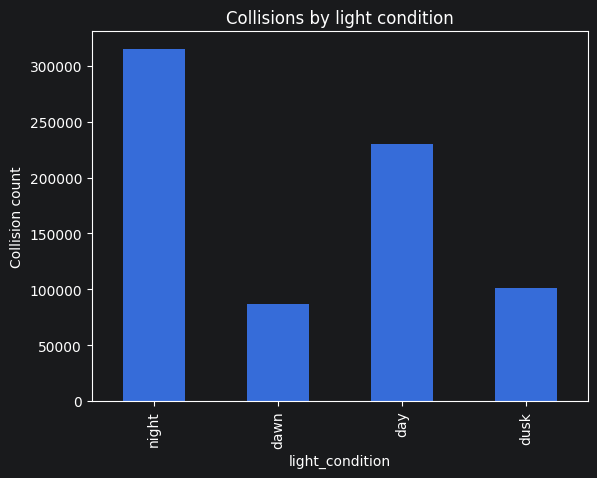

In [9]:
import matplotlib.pyplot as plt

light_counts_plot = daylight_df["light_condition"].value_counts().reindex(
    ["night", "dawn", "day", "dusk"]
)

light_counts_plot.plot(kind="bar")
plt.ylabel("Collision count")
plt.title("Collisions by light condition")
plt.show()

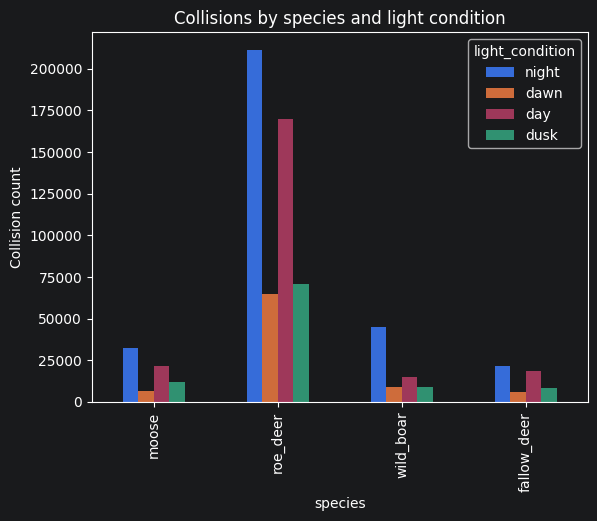

In [10]:
species_order = ["moose", "roe_deer", "wild_boar", "fallow_deer"]

pivot_species_light = (
    daylight_df.groupby(["species", "light_condition"])
    .size()
    .unstack(fill_value=0)
    .reindex(species_order)
)

pivot_species_light = pivot_species_light.reindex(
    columns=["night", "dawn", "day", "dusk"]
)

pivot_species_light.plot(kind="bar")
plt.ylabel("Collision count")
plt.title("Collisions by species and light condition")
plt.show()

In [11]:
df = joined.copy()

df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df = df.dropna(subset=["datetime", "cell_id"]).copy()

df["cell_id"] = df["cell_id"].astype(int)
df["period_start"] = df["datetime"].dt.to_period("M").dt.to_timestamp()
df["hour"] = df["datetime"].dt.hour

def classify_light_proxy(hour):
    if 5 <= hour < 8:
        return "dawn"
    elif 8 <= hour < 17:
        return "day"
    elif 17 <= hour < 21:
        return "dusk"
    else:
        return "night"

df["light_condition"] = df["hour"].apply(classify_light_proxy)

light_counts = (
    df.groupby(["cell_id", "period_start", "light_condition"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

light_cols = [c for c in light_counts.columns if c not in ["cell_id", "period_start"]]

row_sums = light_counts[light_cols].sum(axis=1)
for col in light_cols:
    light_counts[col] = np.where(row_sums > 0, light_counts[col] / row_sums, 0)

light_counts = light_counts.sort_values(["cell_id", "period_start"])

for col in light_cols:
    light_counts[f"{col}_lag1"] = (
        light_counts.groupby("cell_id")[col].shift(1)
    )

lagged_light = light_counts[
    ["cell_id", "period_start"] + [f"{col}_lag1" for col in light_cols]
].fillna(0)

print(lagged_light.head())

light_condition  cell_id period_start  dawn_lag1  day_lag1  dusk_lag1  \
0                     12   2024-05-01        0.0       0.0        0.0   
1                     23   2024-10-01        0.0       0.0        0.0   
2                     28   2016-09-01        0.0       0.0        0.0   
3                     40   2024-05-01        0.0       0.0        0.0   
4                     42   2023-05-01        0.0       0.0        0.0   

light_condition  night_lag1  
0                       0.0  
1                       0.0  
2                       0.0  
3                       0.0  
4                       0.0  


In [12]:

df = joined.copy()

df["period_start"] = df["datetime"].dt.to_period("M").dt.to_timestamp()
df["cell_id"] = df["cell_id"].astype(int)

df["species"] = df["species"].astype(str).str.strip().str.lower()

species_map = {
    "älg": "moose",
    "rådjur": "roe_deer",
    "vildsvin": "wild_boar",
    "dovhjort": "fallow_deer",
}

df["species"] = df["species"].replace(species_map)

relevant_species = ["moose", "roe_deer", "wild_boar", "fallow_deer"]

df = df[df["species"].isin(relevant_species)].copy()

species_counts = (
    df.groupby(["cell_id", "period_start", "species"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

species_counts = species_counts.sort_values(["cell_id", "period_start"])

species_cols = [col for col in species_counts.columns if col not in ["cell_id", "period_start"]]

for col in species_cols:
    species_counts[f"{col}_lag1"] = (
        species_counts.groupby("cell_id")[col].shift(1)
    )

lagged_species = species_counts[
    ["cell_id", "period_start"] + [f"{col}_lag1" for col in species_cols]
].fillna(0)

print(lagged_species.head())

species  cell_id period_start  fallow_deer_lag1  moose_lag1  roe_deer_lag1  \
0             12   2024-05-01               0.0         0.0            0.0   
1             23   2024-10-01               0.0         0.0            0.0   
2             28   2016-09-01               0.0         0.0            0.0   
3             40   2024-05-01               0.0         0.0            0.0   
4             42   2023-05-01               0.0         0.0            0.0   

species  wild_boar_lag1  
0                   0.0  
1                   0.0  
2                   0.0  
3                   0.0  
4                   0.0  


In [13]:
from roads import build_road_features, load_roads_for_study_area, load_roads

roads = load_roads_for_study_area(
    path="C:/Users/Amanda/PycharmProjects/thesis_boogaloo/data/Sverige_Vägtrafiknät_GeoPackage/Sverige_Vägtrafiknät_194602.gpkg",
    gdf_points=gdf,
    buffer_m=2000
)

road_features = build_road_features(
    grid=grid,
    roads=roads,
    keep_only_classes=["bilnät"] #doesnt work lol
)

model_df = cell_month.merge(
    road_features.drop(columns="geometry"),
    on="cell_id",
    how="left"
)

model_df = model_df[model_df["road_length_m"] > 0].copy()

print(model_df.shape)
print(model_df["risk"].value_counts())
print(model_df[["road_length_m", "road_density", "nearest_road_distance_m"]].describe())

(593076, 9)
risk
0    522441
1     70635
Name: count, dtype: int64
       road_length_m  road_density  nearest_road_distance_m
count   5.930760e+05  5.930760e+05            593076.000000
mean    1.453711e+05  1.453711e-03               779.063134
std     1.057012e+05  1.057012e-03              1287.884738
min     2.397217e+01  2.397217e-07                 0.422024
25%     7.116997e+04  7.116997e-04               105.452830
50%     1.304658e+05  1.304658e-03               258.076470
75%     2.053594e+05  2.053594e-03               660.224390
max     1.253238e+06  1.253238e-02              6858.612485


In [14]:
from roads import load_linear_layer_for_study_area, build_linear_features

railways = load_linear_layer_for_study_area(
    path="C:/Users/Amanda/PycharmProjects/thesis_boogaloo/data/Järnvägnät_grundegenskaper/Järnvägsnät_grundegenskaper3_0_GeoPackage.gpkg",
    gdf_points=gdf,
    buffer_m=2000
)

rail_features = build_linear_features(
    grid=grid,
    lines=railways,
    prefix="rail"
)

model_df = model_df.merge(
    rail_features.drop(columns=["geometry", "cell_area_m2"], errors="ignore"),
    on="cell_id",
    how="left"
)

for col in ["rail_length_m", "rail_density", "nearest_rail_distance_m"]:
    model_df[col] = model_df[col].fillna(0)

model_df["rail_near_10km"] = (
    model_df["nearest_rail_distance_m"] < 10000
).astype(int)


In [15]:
from roads import load_linear_layer_for_study_area, build_linear_features

fences = load_linear_layer_for_study_area(
    path="C:/Users/Amanda/PycharmProjects/thesis_boogaloo/data/Barrairanalys/Barriaranalys.gpkg",
    gdf_points=gdf,
    buffer_m=2000,
    layer="barriarer_kvarvarande_vag"
)

fence_features = build_linear_features(
    grid=grid,
    lines=fences,
    prefix="fence"
)

model_df = model_df.merge(
    fence_features.drop(columns=["geometry", "cell_area_m2"], errors="ignore"),
    on="cell_id",
    how="left"
)

for col in ["fence_length_m", "fence_density", "nearest_fence_distance_m"]:
    model_df[col] = model_df[col].fillna(0)

# Create proximity feature
model_df["fence_near_10km"] = (
    model_df["nearest_fence_distance_m"] < 10000
).astype(int)

#print(fence_features[["fence_length_m", "fence_density", "nearest_fence_distance_m"]].describe())
print(model_df["fence_near_10km"].value_counts())
print(model_df["fence_near_10km"].value_counts(normalize=True))

fence_near_10km
0    368940
1    232980
Name: count, dtype: int64
fence_near_10km
0    0.612939
1    0.387061
Name: proportion, dtype: float64


In [16]:
relevant_cell_ids = model_df["cell_id"].unique()
grid_small = grid[grid["cell_id"].isin(relevant_cell_ids)].copy()

print("Original grid:", grid.shape)
print("Filtered grid:", grid_small.shape)

Original grid: (10419, 2)
Filtered grid: (4471, 2)


In [17]:
from weather import build_cell_month_temperature

temperature_features = build_cell_month_temperature(grid=grid_small)

model_df = model_df.merge(
    temperature_features[["cell_id", "period_start", "temp_mean", "temp_min", "temp_max"]],
    on=["cell_id", "period_start"],
    how="left"
)

model_df = model_df.dropna(subset=["temp_mean", "temp_min", "temp_max"]).copy()

model_df = model_df.merge(
    lagged_species,
    on=["cell_id", "period_start"],
    how="left"
)

lag_cols = ["moose_lag1", "roe_deer_lag1", "wild_boar_lag1", "fallow_deer_lag1"]

for col in lag_cols:
    if col in model_df.columns:
        model_df[col] = model_df[col].fillna(0)

model_df = model_df.merge(
    lagged_light,
    on=["cell_id", "period_start"],
    how="left"
)

light_lag_cols = [c for c in lagged_light.columns if c not in ["cell_id", "period_start"]]
for col in light_lag_cols:
    model_df[col] = model_df[col].fillna(0)

C:\Users\Amanda\PycharmProjects\thesis_boogaloo\src\weather.py:131: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids["geometry"] = centroids.geometry.centroid


Parsed columns for station 72500: ['Datum', 'Tid (UTC)', 'Lufttemperatur', 'Kvalitet', 'Unnamed: 4', 'Tidsutsnitt:']
date_col: Datum
time_col: Tid (UTC)
temp_col: Lufttemperatur
Metadata request failed for station 11032: 404
Parsed columns for station 84140: ['Datum', 'Tid (UTC)', 'Lufttemperatur', 'Kvalitet', 'Unnamed: 4', 'Tidsutsnitt:']
date_col: Datum
time_col: Tid (UTC)
temp_col: Lufttemperatur
Parsed columns for station 125490: ['Datum', 'Tid (UTC)', 'Lufttemperatur', 'Kvalitet', 'Unnamed: 4', 'Tidsutsnitt:']
date_col: Datum
time_col: Tid (UTC)
temp_col: Lufttemperatur
Parsed columns for station 162015: ['Datum', 'Tid (UTC)', 'Lufttemperatur', 'Kvalitet', 'Unnamed: 4', 'Tidsutsnitt:']
date_col: Datum
time_col: Tid (UTC)
temp_col: Lufttemperatur


In [18]:
import numpy as np

model_df["month"] = model_df["period_start"].dt.month
model_df["month_sin"] = np.sin(2 * np.pi * model_df["month"] / 12)
model_df["month_cos"] = np.cos(2 * np.pi * model_df["month"] / 12)
model_df["is_hunting_season"] = model_df["month"].isin([10, 11]).astype(int)

features = [
    "road_length_m",
    "road_density",
    "nearest_road_distance_m",

    "rail_length_m",
    "rail_density",
    "rail_near_10km",

    "fence_length_m",
    "fence_density",
    "fence_near_10km",

    "temp_mean",
    "temp_min",
    "temp_max",

    "moose_lag1",
    "roe_deer_lag1",
    "wild_boar_lag1",
    "fallow_deer_lag1",

    "night_lag1",
    "dawn_lag1",
    "day_lag1",
    "dusk_lag1",

    "month_sin",
    "month_cos",
    "is_hunting_season",
]
model_df_clean = model_df.dropna(subset=features).copy()

print("After dropna:", model_df_clean.shape)
print(model_df_clean["period_start"].value_counts().sort_index())

After dropna: (172365, 32)
period_start
2015-01-01    1396
2015-02-01    1396
2015-03-01    1383
2015-04-01    1386
2015-05-01    1388
              ... 
2025-08-01    1247
2025-09-01    1240
2025-10-01    1245
2025-11-01    1247
2025-12-01    1242
Name: count, Length: 132, dtype: int64


In [32]:
def make_expanding_time_splits(months, min_train_months=12, test_horizon=1):
    months = list(months)
    splits = []

    for train_end in range(min_train_months, len(months) - test_horizon + 1):
        train_months = months[:train_end]
        test_months = months[train_end:train_end + test_horizon]
        splits.append((train_months, test_months))

    return splits


In [33]:
months = sorted(model_df_clean["period_start"].unique())

splits = make_expanding_time_splits(
    months,
    min_train_months=12,
    test_horizon=1
)

print("Number of folds:", len(splits))

Number of folds: 120


In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, accuracy_score
)


def evaluate_time_splits(model_df, features, target, splits):
    import pandas as pd

    results = []

    for fold_idx, (train_months, test_months) in enumerate(splits, start=1):

        train = model_df[model_df["period_start"].isin(train_months)].copy()
        test = model_df[model_df["period_start"].isin(test_months)].copy()

        X_train = train[features]
        y_train = train[target]
        X_test = test[features]
        y_test = test[target]

        if len(test) == 0 or y_train.nunique() < 2 or y_test.nunique() < 2:
            continue

        # Logistic Regression
        logreg = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=3000, class_weight="balanced"))
        ])

        logreg.fit(X_train, y_train)
        y_pred_lr = logreg.predict(X_test)
        y_prob_lr = logreg.predict_proba(X_test)[:, 1]

        results.append({
            "fold": fold_idx,
            "model": "logreg",
            "auc": roc_auc_score(y_test, y_prob_lr),
            "precision": precision_score(y_test, y_pred_lr, zero_division=0),
            "recall": recall_score(y_test, y_pred_lr, zero_division=0),
            "f1": f1_score(y_test, y_pred_lr, zero_division=0),
            "accuracy": accuracy_score(y_test, y_pred_lr),
        })

        # Random Forest
        rf = RandomForestClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

        rf.fit(X_train, y_train)
        y_pred_rf = rf.predict(X_test)
        y_prob_rf = rf.predict_proba(X_test)[:, 1]

        results.append({
            "fold": fold_idx,
            "model": "rf",
            "auc": roc_auc_score(y_test, y_prob_rf),
            "precision": precision_score(y_test, y_pred_rf, zero_division=0),
            "recall": recall_score(y_test, y_pred_rf, zero_division=0),
            "f1": f1_score(y_test, y_pred_rf, zero_division=0),
            "accuracy": accuracy_score(y_test, y_pred_rf),
        })

    return pd.DataFrame(results)

In [35]:
results_df = evaluate_time_splits(
    model_df=model_df_clean,
    features=features,
    target="risk",
    splits=splits
)

print(results_df.head())

   fold   model       auc  precision    recall        f1  accuracy
0     1  logreg  0.960412   0.468310  0.970803  0.631829  0.888167
1     1      rf  0.944630   0.727273  0.116788  0.201258  0.908369
2     2  logreg  0.961987   0.233813  1.000000  0.379009  0.846320
3     2      rf  0.959093   0.561404  0.492308  0.524590  0.958153
4     3  logreg  0.965723   0.172691  0.977273  0.293515  0.850649


In [36]:
summary = (
    results_df.groupby("model")[["auc", "precision", "recall", "f1", "accuracy"]]
    .agg(["mean", "std"])
    .round(3)
)

print(summary)

          auc        precision        recall            f1        accuracy  \
         mean    std      mean    std   mean    std   mean    std     mean   
model                                                                        
logreg  0.967  0.006     0.421  0.089  0.961  0.027  0.580  0.088    0.875   
rf      0.966  0.008     0.765  0.083  0.472  0.120  0.575  0.110    0.939   

               
          std  
model          
logreg  0.017  
rf      0.013  


In [42]:
import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

print(feature_importance)

roe_deer_lag1              0.194514
road_density               0.146537
road_length_m              0.115781
fence_near_10km            0.069855
night_lag1                 0.068123
fence_length_m             0.051526
fence_density              0.044442
dawn_lag1                  0.035836
dusk_lag1                  0.033156
day_lag1                   0.032909
temp_mean                  0.029952
temp_min                   0.029913
temp_max                   0.029371
nearest_road_distance_m    0.022931
rail_density               0.015032
rail_length_m              0.014032
month_sin                  0.013076
month_cos                  0.013072
wild_boar_lag1             0.012215
rail_near_10km             0.009206
moose_lag1                 0.008889
fallow_deer_lag1           0.005948
is_hunting_season          0.003682
dtype: float64


In [24]:
model_df_clean.to_csv("C:/Users/Amanda/PycharmProjects/thesis_boogaloo/data/processed/model_df_clean_2025.csv", index=False)

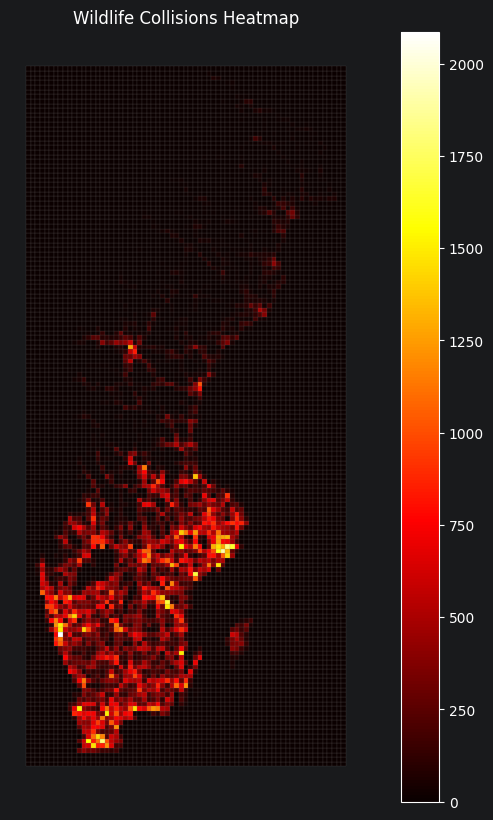

In [25]:
cell_totals = (
    joined.groupby("cell_id")
    .size()
    .reset_index(name="collision_count")
)
grid_heatmap = grid.merge(cell_totals, on="cell_id", how="left")
grid_heatmap["collision_count"] = grid_heatmap["collision_count"].fillna(0)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

grid_heatmap.plot(
    column="collision_count",
    cmap="hot",        # color style
    linewidth=0.1,
    edgecolor="grey",
    legend=True,
    ax=ax
)

ax.set_title("Wildlife Collisions Heatmap")
ax.set_axis_off()

plt.show()


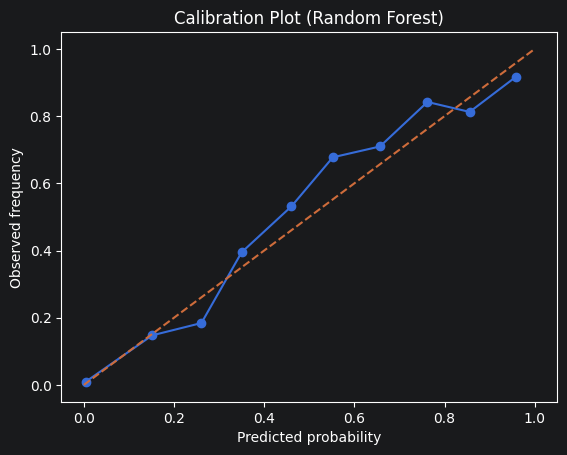

In [27]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, y_prob_rf, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')  # perfect calibration line

plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Plot (Random Forest)")
plt.show()

In [28]:
from sklearn.calibration import CalibratedClassifierCV

rf_calibrated = CalibratedClassifierCV(rf, method="isotonic", cv=3)
rf_calibrated.fit(X_train, y_train)

y_prob_rf_cal = rf_calibrated.predict_proba(X_test)[:, 1]

In [29]:
model_df_clean["risk_prob"] = rf.predict_proba(model_df_clean[features])[:, 1]
cell_risk = (
    model_df_clean.groupby("cell_id")["risk_prob"]
    .mean()
    .reset_index()
)
grid_risk = grid.merge(cell_risk, on="cell_id", how="left")
grid_risk["risk_prob"] = grid_risk["risk_prob"].fillna(0)

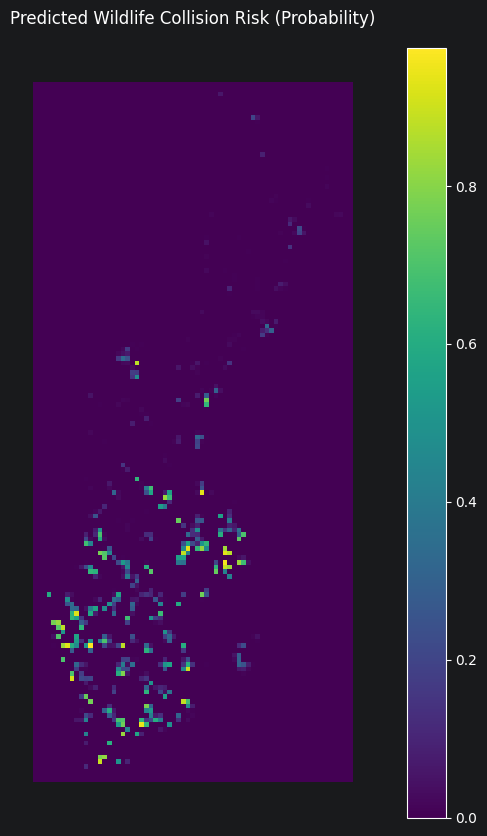

In [30]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

grid_risk.plot(
    column="risk_prob",
    legend=True,
    ax=ax
)

ax.set_title("Predicted Wildlife Collision Risk (Probability)")
ax.set_axis_off()

plt.show()